# 🎥 Intelligent Video-Based Violence Detection System
## مشروع تخرج: نظام الكشف عن العنف باستخدام التعلم العميق

### 📋 نظرة عامة
يهدف هذا المشروع إلى تطوير نظام ذكي قادر على تحليل مقاطع الفيديو وتصنيفها تلقائياً إلى "عنف" أو "غير عنف".

### 🧠 المنهجية (Architecture)
يستخدم النظام نهجاً هجيناً (Hybrid Model) يجمع بين:
1. **MobileNetV2:** لاستخراج الميزات البصرية (Spatial Features) من كل إطار بدقة وسرعة عالية.
2. **Bidirectional LSTM:** لتحليل التسلسل الزمني (Temporal Features) وفهم سياق الحركة عبر الزمن.

### ⚙️ التقنيات المستخدمة
* **TensorFlow/Keras:** لبناء وتدريب الشبكات العصبية.
* **OpenCV:** لمعالجة الفيديو واستخراج الإطارات.
* **Gradio:** لبناء واجهة مستخدم تفاعلية لعرض النتائج.

# **تهيئة البيئة واستيراد المكتبات وتحديد الثوابت.**

In [7]:
# 1. التثبيت والاستيراد (Setup & Imports)
!pip install tensorflow opencv-python scikit-learn gradio kaggle -q

import os
import math
import json
import random
import numpy as np
import cv2
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# إعدادات تسريع التدريب باستخدام Mixed Precision (اختياري حسب نوع GPU)
try:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print('✅ Using mixed precision policy: mixed_float16 (Faster Training)')
except Exception as e:
    print('⚠️ Mixed precision not available, using float32')

# الثوابت والتهيئة (Configuration)
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# أبعاد الصورة وطول التسلسل
IMAGE_HEIGHT, IMAGE_WIDTH = 128, 128
SEQUENCE_LENGTH = 16  # عدد الإطارات لكل فيديو
BATCH_SIZE = 8
EPOCHS = 20  # عدد دورات التدريب

# مسارات الملفات
DATA_DIR = './data/real-life-violence-situations-dataset'
WORK_DIR = './workdir'
os.makedirs(WORK_DIR, exist_ok=True)
MODEL_PATH = os.path.join(WORK_DIR, 'violence_model.h5')

print("✅ البيئة جاهزة وتم تحديد الثوابت.")

✅ Using mixed precision policy: mixed_float16 (Faster Training)
✅ البيئة جاهزة وتم تحديد الثوابت.


# **إعداد Kaggle API لتحميل البيانات.**

In [8]:
# 2. إعداد Kaggle (Kaggle Setup)
# هذه الخطوة تطلب منك رفع ملف kaggle.json إذا لم يكن موجوداً
def setup_kaggle():
    kaggle_dir = Path.home() / '.kaggle'
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    kaggle_json_path = kaggle_dir / 'kaggle.json'

    if not kaggle_json_path.exists():
        print("📂 يرجى رفع ملف kaggle.json الخاص بك الآن:")
        from google.colab import files
        uploaded = files.upload()
        if 'kaggle.json' in uploaded:
            # نقل الملف للمسار الصحيح
            !mv kaggle.json /root/.kaggle/kaggle.json
            !chmod 600 /root/.kaggle/kaggle.json
            print("✅ تم إعداد Kaggle بنجاح.")
            return True
        else:
            print("❌ لم يتم رفع الملف.")
            return False
    return True

if setup_kaggle():
    # تحميل البيانات
    if not os.path.exists(DATA_DIR):
        print("⬇️ جاري تحميل البيانات من Kaggle...")
        !kaggle datasets download -d mohamedmustafa/real-life-violence-situations-dataset -p ./data --unzip
        print("✅ تم تحميل وفك ضغط البيانات.")
    else:
        print("✅ البيانات موجودة مسبقاً.")

⬇️ جاري تحميل البيانات من Kaggle...
Dataset URL: https://www.kaggle.com/datasets/mohamedmustafa/real-life-violence-situations-dataset
License(s): copyright-authors
 99% 3.53G/3.58G [00:11<00:00, 628MB/s]
100% 3.58G/3.58G [00:11<00:00, 341MB/s]
✅ تم تحميل وفك ضغط البيانات.


# **دوال المعالجة المسبقة للفيديو (Preprocessing).**

In [9]:
# 3. معالجة الفيديو (Video Processing Functions)

def extract_frames(video_path, seq_length=SEQUENCE_LENGTH):
    """
    تقوم هذه الدالة بقراءة الفيديو واستخراج عدد ثابت من الإطارات (16 إطار)،
    ثم تغيير حجمها ومعالجتها لتناسب شبكة MobileNetV2.
    """
    try:
        cap = cv2.VideoCapture(str(video_path))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        # التأكد من صلاحية الفيديو
        if total_frames < seq_length:
            cap.release()
            return None

        # اختيار إطارات موزعة بانتظام على طول الفيديو
        indices = np.linspace(0, total_frames - 1, seq_length, dtype=int)
        frames = []

        for i in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if not ret:
                continue

            # تحويل الألوان من BGR إلى RGB
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            # تغيير الحجم
            frame = cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT))
            # المعالجة المسبقة الخاصة بـ MobileNet
            frame = preprocess_input(frame.astype('float32'))
            frames.append(frame)

        cap.release()

        if len(frames) < seq_length:
            return None

        return np.array(frames)
    except Exception as e:
        return None

# مولد البيانات (Data Generator) لتوفير الذاكرة
class VideoDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, paths, labels, batch_size, shuffle=True):
        self.paths = paths
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.paths))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.paths) / self.batch_size)

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_x = []
        batch_y = []

        for i in batch_indices:
            video = extract_frames(self.paths[i])
            if video is not None:
                batch_x.append(video)
                batch_y.append(self.labels[i])

        return np.array(batch_x), np.array(batch_y)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

print("✅ دوال المعالجة ومولد البيانات جاهزة.")

✅ دوال المعالجة ومولد البيانات جاهزة.


# **اكتشاف البيانات وتقسيمها.**

In [16]:
# 4. التحقق من مسار البيانات وتصحيحها إن لزم
import os

# التحقق من محتويات مجلد data
if os.path.exists('./data'):
    print("📂 مجلد data موجود. جاري فحص المحتويات...")
    contents = os.listdir('./data')
    print(f"   المحتويات: {contents}")

    # البحث عن المجلد الفرعي الصحيح
    found = False
    for item in contents:
        full_path = os.path.join('./data', item)
        if os.path.isdir(full_path):
            DATA_DIR = full_path  # تحديث المسار بالاسم الصحيح الموجود فعلياً
            print(f"✅ تم تحديث مسار البيانات ليصبح: {DATA_DIR}")
            found = True
            break

    if not found:
        print("⚠️ تنبيه: لم يتم العثور على مجلدات فرعية داخل data. ربما فشل فك الضغط؟")
else:
    print("❌ خطأ: مجلد ./data غير موجود أصلاً! تأكد من تشغيل الخلية رقم 3 بنجاح.")

📂 مجلد data موجود. جاري فحص المحتويات...
   المحتويات: ['real life violence situations', 'Real Life Violence Dataset']
✅ تم تحديث مسار البيانات ليصبح: ./data/real life violence situations


In [12]:
# 5. تجهيز وتقسيم البيانات (Data Splitting)

def load_data_paths(data_dir):
    classes = sorted(os.listdir(data_dir))
    paths = []
    labels = []

    print(f"🏷️ الفئات المكتشفة: {classes}")

    for label_idx, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name)
        files = [os.path.join(class_dir, f) for f in os.listdir(class_dir) if f.endswith(('.mp4', '.avi'))]
        paths.extend(files)
        labels.extend([label_idx] * len(files))
        print(f"   - {class_name}: {len(files)} videos")

    return paths, labels, classes

# Temporary adjustment of DATA_DIR to match observed file structure
# Based on previous output, DATA_DIR was './data/real life violence situations'
# and inside it was 'Real Life Violence Dataset', which likely contains the actual class folders.
adjusted_data_dir = os.path.join(DATA_DIR, 'Real Life Violence Dataset')
if os.path.exists(adjusted_data_dir) and len(os.listdir(adjusted_data_dir)) > 0:
    print(f"ℹ️ تم تعديل مسار البيانات إلى: {adjusted_data_dir} لاستيعاب بنية المجلدات.")
    DATA_DIR = adjusted_data_dir
else:
    print(f"⚠️ لم يتم تعديل مسار البيانات، سيتم استخدام: {DATA_DIR}. قد يشير ذلك إلى مشكلة في بنية المجلدات.")

# تحميل المسارات
paths, labels, CLASS_NAMES = load_data_paths(DATA_DIR)

# التقسيم: 80% تدريب، 20% اختبار
train_paths, val_paths, train_labels, val_labels = train_test_split(
    paths, labels, test_size=0.2, stratify=labels, random_state=SEED
)

print(f"\n📊 بيانات التدريب: {len(train_paths)} فيديو")
print(f"📊 بيانات التحقق: {len(val_paths)} فيديو")

# إنشاء المولدات
train_gen = VideoDataGenerator(train_paths, train_labels, BATCH_SIZE)
val_gen = VideoDataGenerator(val_paths, val_labels, BATCH_SIZE, shuffle=False)

ℹ️ تم تعديل مسار البيانات إلى: ./data/real life violence situations/Real Life Violence Dataset لاستيعاب بنية المجلدات.
🏷️ الفئات المكتشفة: ['NonViolence', 'Violence']
   - NonViolence: 1000 videos
   - Violence: 1000 videos

📊 بيانات التدريب: 1600 فيديو
📊 بيانات التحقق: 400 فيديو


# **بناء هيكلية النموذج (CNN + LSTM).**

In [13]:
# 6. بناء النموذج (Model Architecture)

def build_hybrid_model(num_classes):
    # الجزء الأول: استخراج الميزات المكانية (CNN)
    base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3))

    # تجميد طبقات MobileNet لتسريع التدريب والحفاظ على الأوزان المدربة
    base_model.trainable = False

    inputs = layers.Input(shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3))

    # تطبيق CNN على كل إطار في الفيديو (TimeDistributed)
    x = layers.TimeDistributed(base_model)(inputs)
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)

    # الجزء الثاني: تحليل الزمن (RNN/LSTM)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=False, dropout=0.3))(x)

    # طبقات التصنيف النهائية
    x = layers.BatchNormalization()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="Violence_Detector_Net")
    return model

model = build_hybrid_model(len(CLASS_NAMES))
model.summary()

# تجميع النموذج
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "Violence_Detector_Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16, 128, 128,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 16, 4, 4, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 16, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │     1,442,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,718,402 (14.18 MB)

 Trainable params: 1,459,906 (5.57 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

# **بدء عملية التدريب.**

In [14]:
# 7. تدريب النموذج (Training)

# إعدادات الحفظ والتوقف المبكر
callbacks_list = [
    callbacks.ModelCheckpoint(MODEL_PATH, save_best_only=True, monitor='val_accuracy', mode='max'),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

print("🚀 بدء التدريب...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_list
)
print("✅ انتهى التدريب.")

🚀 بدء التدريب...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6554 - loss: 0.7181

200/200 ━━━━━━━━━━━━━━━━━━━━ 710s 3s/step - accuracy: 0.6556 - loss: 0.7177 - val_accuracy: 0.8421 - val_loss: 0.3762 - learning_rate: 1.0000e-04
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8132 - loss: 0.4211

200/200 ━━━━━━━━━━━━━━━━━━━━ 597s 3s/step - accuracy: 0.8132 - loss: 0.4210 - val_accuracy: 0.8947 - val_loss: 0.2559 - learning_rate: 1.0000e-04
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8507 - loss: 0.3022

200/200 ━━━━━━━━━━━━━━━━━━━━ 594s 3s/step - accuracy: 0.8507 - loss: 0.3023 - val_accuracy: 0.9073 - val_loss: 0.2141 - learning_rate: 1.0000e-04
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8742 - loss: 0.3076

200/200 ━━━━━━━━━━━━━━━━━━━━ 595s 3s/step - accuracy: 0.8742 - loss: 0.3075 - val_accuracy: 0.9198 - val_loss: 0.1911 - learning_rate: 1.0000e-04
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9101 - loss: 0.2331

200/200 ━━━━━━━━━━━━━━━━━━━━ 595s 3s/step - accuracy: 0.9101 - loss: 0.2331 - val_accuracy: 0.9273 - val_loss: 0.1902 - learning_rate: 1.0000e-04
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9121 - loss: 0.2008

200/200 ━━━━━━━━━━━━━━━━━━━━ 595s 3s/step - accuracy: 0.9121 - loss: 0.2009 - val_accuracy: 0.9474 - val_loss: 0.1476 - learning_rate: 1.0000e-04
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 595s 3s/step - accuracy: 0.9241 - loss: 0.1923 - val_accuracy: 0.9449 - val_loss: 0.1370 - learning_rate: 1.0000e-04
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 595s 3s/step - accuracy: 0.8954 - loss: 0.2302 - val_accuracy: 0.9398 - val_loss: 0.1704 - learning_rate: 1.0000e-04
Epoch 9/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 600s 3s/step - accuracy: 0.9228 - loss: 0.1926 - val_accuracy: 0.9474 - val_loss: 0.1574 - learning_rate: 1.0000e-04
Epoch 10/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 595s 3s/step - accuracy: 0.9345 - loss: 0.1495 - val_accuracy: 0.9474 - val_loss: 0.1406 - learning_rate: 1.0000e-04
Epoch 11/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9417 - loss: 0.1433

200/200 ━━━━━━━━━━━━━━━━━━━━ 595s 3s/step - accuracy: 0.9417 - loss: 0.1433 - val_accuracy: 0.9499 - val_loss: 0.1473 - learning_rate: 5.0000e-05
Epoch 12/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 594s 3s/step - accuracy: 0.9402 - loss: 0.1538 - val_accuracy: 0.9499 - val_loss: 0.1382 - learning_rate: 5.0000e-05
Epoch 13/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 595s 3s/step - accuracy: 0.9427 - loss: 0.1473 - val_accuracy: 0.9424 - val_loss: 0.1409 - learning_rate: 5.0000e-05
Epoch 14/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 598s 3s/step - accuracy: 0.9399 - loss: 0.1350 - val_accuracy: 0.9424 - val_loss: 0.1387 - learning_rate: 2.5000e-05
Epoch 15/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 601s 3s/step - accuracy: 0.9569 - loss: 0.1120 - val_accuracy: 0.9424 - val_loss: 0.1450 - learning_rate: 2.5000e-05
Epoch 16/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 603s 3s/step - accuracy: 0.9333 - loss: 0.1617 - val_accuracy: 0.9449 - val_loss: 0.1391 - learning_rate: 2.5000e-05
✅ انتهى التدريب.


## **الرسوم البيانية**

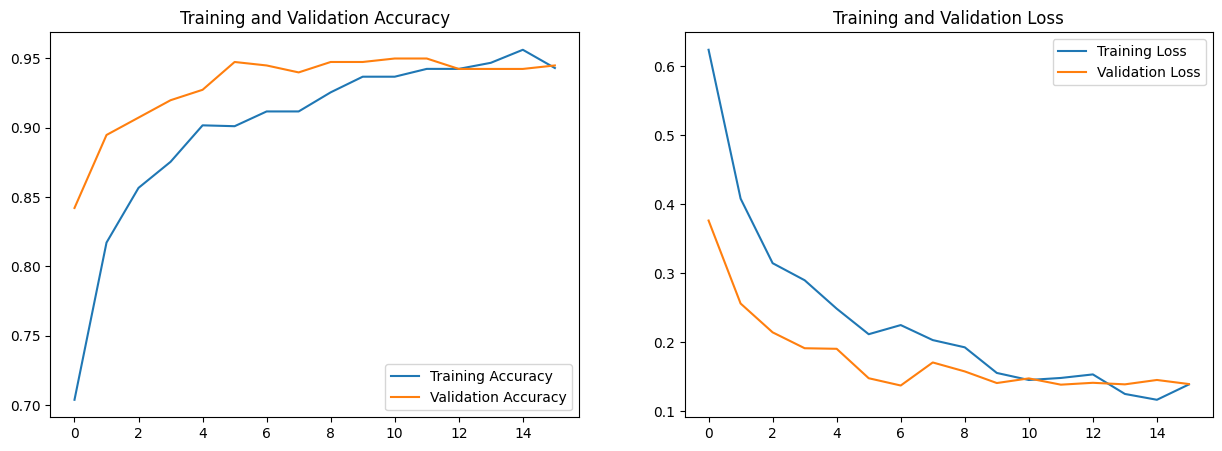

In [15]:
# 8. الرسوم البيانية

import matplotlib.pyplot as plt

# التأكد من أن المتغير history موجود من الخلية السابقة
if 'history' in globals():
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(15, 5))

    # رسم الدقة (Accuracy)
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # رسم الخسارة (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')

    plt.show()
else:
    print("⚠️ لم يتم العثور على سجل التدريب history. تأكد من تشغيل خلية التدريب أولاً.")

# **التقييم ورسم مصفوفة الارتباك.**

In [17]:
# 9. تقييم النموذج (Evaluation)

print("🔍 جاري حساب دقة النموذج على بيانات الاختبار...")
y_true = []
y_pred = []

# التكرار على بيانات التحقق للتنبؤ
for i in range(len(val_gen)):
    x_batch, y_batch = val_gen[i]
    preds = model.predict(x_batch, verbose=0)
    y_true.extend(y_batch)
    y_pred.extend(np.argmax(preds, axis=1))

# عرض التقرير
print("\n📊 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

print("\n🧩 Confusion Matrix:\n")
print(confusion_matrix(y_true, y_pred))

🔍 جاري حساب دقة النموذج على بيانات الاختبار...

📊 Classification Report:

              precision    recall  f1-score   support

 NonViolence       0.99      0.91      0.95       199
    Violence       0.92      0.99      0.95       200

    accuracy                           0.95       399
   macro avg       0.95      0.95      0.95       399
weighted avg       0.95      0.95      0.95       399


🧩 Confusion Matrix:

[[181  18]
 [  2 198]]


## **كود الحفظ**

In [20]:
# 10. حفظ النموذج النهائي
model.save(MODEL_PATH)
print(f"✅ تم حفظ النموذج في المسار: {MODEL_PATH}")

# محاولة تنزيل النموذج تلقائياً إلى جهازك
try:
    from google.colab import files
    print("⬇️ جاري تحضير الملف للتنزيل...")
    files.download(MODEL_PATH)
except Exception as e:
    print(f"⚠️ لم يتم التنزيل تلقائياً (قد يكون بسبب إعدادات المتصفح). يمكنك تنزيله يدوياً من القائمة الجانبية: {MODEL_PATH}")

✅ تم حفظ النموذج في المسار: ./workdir/violence_model.h5
⬇️ جاري تحضير الملف للتنزيل...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **التحقق باستخدام عينات من البيانات**

In [22]:
# 11. عرض عينات من التنبؤات (Sample Predictions)

# التأكد من تحميل النموذج أو توفره في الذاكرة
final_model = None
if os.path.exists(MODEL_PATH):
    try:
        final_model = tf.keras.models.load_model(MODEL_PATH)
        print("✅ تم تحميل النموذج من الملف.")
    except Exception as e:
        print(f"⚠️ تعذر تحميل النموذج من الملف: {e}")

if final_model is None and 'model' in globals():
    final_model = model
    print("⚠️ سيتم استخدام النموذج الموجود حالياً في الذاكرة.")

if final_model:
    print("🎥 عرض عينات من التنبؤات على بيانات التحقق:")

    # اختيار 5 عينات عشوائية (أو أقل إذا كانت البيانات قليلة)
    num_samples = min(5, len(val_paths))
    if num_samples > 0:
        sample_indices = np.random.choice(len(val_paths), num_samples, replace=False)

        for i, idx in enumerate(sample_indices):
            video_path = val_paths[idx]
            true_label_idx = val_labels[idx]
            true_label_name = CLASS_NAMES[true_label_idx]

            print(f"\n--- Sample {i+1} ---")
            print(f"مسار الفيديو: {video_path}")
            print(f"التصنيف الحقيقي: {true_label_name}")

            # استخراج الإطارات للفيديو
            frames = extract_frames(video_path)

            if frames is not None:
                # إضافة بعد batch size للتنبؤ بالنموذج
                input_data = np.expand_dims(frames, axis=0)

                # إجراء التنبؤ
                predictions = final_model.predict(input_data, verbose=0)[0]
                predicted_class_idx = np.argmax(predictions)
                predicted_class_name = CLASS_NAMES[predicted_class_idx]
                confidence = predictions[predicted_class_idx]

                print(f"التصنيف المتوقع: {predicted_class_name} (بثقة: {confidence:.2f})")

                # التحقق من صحة التنبؤ
                if predicted_class_idx == true_label_idx:
                    print("✅ تنبؤ صحيح")
                else:
                    print("❌ تنبؤ خاطئ")
            else:
                print("❌ لم نتمكن من معالجة الفيديو (عدد الإطارات غير كافٍ أو ملف تالف).")
    else:
        print("⚠️ لا توجد بيانات تحقق لعرض العينات.")
else:
    print("❌ النموذج غير متاح. يرجى تدريب النموذج أولاً.")

✅ تم تحميل النموذج من الملف.
🎥 عرض عينات من التنبؤات على بيانات التحقق:

--- Sample 1 ---
مسار الفيديو: ./data/real life violence situations/Real Life Violence Dataset/NonViolence/NV_332.mp4
التصنيف الحقيقي: NonViolence
التصنيف المتوقع: NonViolence (بثقة: 0.99)
✅ تنبؤ صحيح

--- Sample 2 ---
مسار الفيديو: ./data/real life violence situations/Real Life Violence Dataset/Violence/V_811.mp4
التصنيف الحقيقي: Violence
التصنيف المتوقع: Violence (بثقة: 0.99)
✅ تنبؤ صحيح

--- Sample 3 ---
مسار الفيديو: ./data/real life violence situations/Real Life Violence Dataset/NonViolence/NV_532.mp4
التصنيف الحقيقي: NonViolence
التصنيف المتوقع: NonViolence (بثقة: 1.00)
✅ تنبؤ صحيح

--- Sample 4 ---
مسار الفيديو: ./data/real life violence situations/Real Life Violence Dataset/Violence/V_883.mp4
التصنيف الحقيقي: Violence
التصنيف المتوقع: Violence (بثقة: 1.00)
✅ تنبؤ صحيح

--- Sample 5 ---
مسار الفيديو: ./data/real life violence situations/Real Life Violence Dataset/Violence/V_416.mp4
التصنيف الحقيقي: Violence

# **واجهة Gradio.**

In [21]:
# 12. واجهة التطبيق الاحترافية (Gradio with Video Overlay)
import gradio as gr

# تحميل أفضل نموذج (للتأكد)
if os.path.exists(MODEL_PATH):
    final_model = models.load_model(MODEL_PATH)
else:
    final_model = model # استخدام النموذج الموجود في الذاكرة حالياً

def predict_video_with_overlay(video_path):
    if video_path is None: return None

    cap = cv2.VideoCapture(video_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    output_path = 'output_annotated.mp4'
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frames_queue = []
    label = "Analyzing..."
    color = (255, 255, 0) # أصفر للانتظار

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        # معالجة الإطار للنموذج
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        resized = cv2.resize(rgb_frame, (IMAGE_WIDTH, IMAGE_HEIGHT))
        normalized = preprocess_input(resized.astype('float32'))
        frames_queue.append(normalized)

        # التنبؤ عند اكتمال 16 إطار
        if len(frames_queue) == SEQUENCE_LENGTH:
            input_data = np.expand_dims(np.array(frames_queue), axis=0)
            pred = final_model.predict(input_data, verbose=0)[0]
            idx = np.argmax(pred)
            conf = pred[idx]

            current_class = CLASS_NAMES[idx]
            label = f"{current_class} ({conf:.1%})"

            # تغيير اللون: أحمر للعنف، أخضر لغير العنف
            if current_class == 'Violence':
                color = (0, 0, 255) # Red
            else:
                color = (0, 255, 0) # Green

            frames_queue.pop(0) # إزالة أقدم إطار

        # الكتابة على الفيديو
        cv2.putText(frame, label, (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 3, cv2.LINE_AA)
        out.write(frame)

    cap.release()
    out.release()
    return output_path

# تشغيل الواجهة
iface = gr.Interface(
    fn=predict_video_with_overlay,
    inputs=gr.Video(label="رفع الفيديو (Upload Video)"),
    outputs=gr.Video(label="النتيجة مع التحليل (Result)"),
    title="🛡️ Violence Detection System (Pro)",
    description="نظام ذكي يقوم بتحليل الفيديو وكتابة النتيجة (عنف / غير عنف) مباشرة على الفيديو.",
    examples=[]
)

iface.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://9be9e794d36126eeab.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://9be9e794d36126eeab.gradio.live
